In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
'''
import torch
import torch.nn.functional as F
'''
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from scipy.stats import pearsonr

from jax import jit
from jax import numpy as jnp
from matplotlib import pyplot as plt

from jwave.geometry import TimeAxis
from jwave.geometry import Medium
from jwave.geometry import Domain
from jwave.geometry import Sensors, circ_mask, points_on_circle


from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import *
from jwave.geometry import circ_mask
from jwave.utils import show_field

import fbpinn_wave as fw
from fbpinn_wave import ExactAny, Wave1DMultiPulse

from fbpinns.problems import WaveEquationConstantVelocity3D
from fbpinns.analysis import FBPINN_solution
from fbpinns.analysis import load_model
'''
class GaussianPulseOptimizer:
    def __init__(self, num_gaussians, cov_matrix, device='cuda'):
        self.num_gaussians = num_gaussians
        self.device = device
        
        self.means = torch.randn(num_gaussians, 2, device=device, dtype=torch.float32, requires_grad=True)
        
        self.weights = torch.rand(num_gaussians, device=device, dtype=torch.float32, requires_grad=True)
        
        self.cov_matrix = torch.tensor(cov_matrix, device=device, dtype=torch.float32)

    def gaussian_kernel(self, x, mean, cov_matrix):
        diff = x - mean
        return torch.exp(-0.5 * torch.sum(torch.matmul(diff, torch.inverse(cov_matrix)) * diff, dim=1))

    def model(self, x):
        pulses = torch.stack([self.weights[i] * self.gaussian_kernel(x, self.means[i], self.cov_matrix) 
                              for i in range(self.num_gaussians)], dim=1)
        return torch.sum(pulses, dim=1)

    def fit(self, f, x, num_epochs=1000, lr=0.001):
        optimizer = torch.optim.Adam([self.means, self.weights], lr=lr)
        loss_fn = torch.nn.MSELoss()

        for epoch in range(num_epochs):
            optimizer.zero_grad()
            
            y_pred = self.model(x)
            
            loss = loss_fn(y_pred, f(x))
            
            loss.backward()
            optimizer.step()

            if epoch % 250 == 0:
                print(f"Epoch {epoch}, Loss: {loss.item()}")

        return self.means, self.weights

'''
def rect_2d(min, max, x):
    mask_x = (x[0] >= min[0]) & (x[0] <= max[0])
    mask_y = (x[1] >= min[1]) & (x[1] <= max[1])
    
    r = torch.ones_like(x[0], dtype=int)
    r[~(mask_x & mask_y)] = 0 
    return r

def smooth_rect_2d(min, max, x, k=50):
    """
    Ventana rectangular suave en 2D.
    
    min, max: tuplas con coordenadas mínimas y máximas (x_min, y_min), (x_max, y_max)
    x: tupla de tensores (X, Y) como mallas 2D
    k: parámetro de suavidad (mayor k => transición más brusca)
    
    return: tensor 2D con valores entre 0 y 1
    """
    x_min, y_min = min
    x_max, y_max = max
    X, Y = x

    # Aplicamos funciones sigmoides para cada borde
    sx1 = torch.sigmoid(k * (X - x_min))
    sx2 = torch.sigmoid(k * (x_max - X))
    sy1 = torch.sigmoid(k * (Y - y_min))
    sy2 = torch.sigmoid(k * (y_max - Y))

    smooth_mask = sx1 * sx2 * sy1 * sy2

    return smooth_mask

def f(x):
    return (torch.exp(-0.5*(x[:,0])**2/5**2) + torch.exp(-0.5*(x[:,1])**2/5**2))*smooth_rect_2d([-20, -20], [20, 20], [x[:,0], x[:,1]], k=0.5)

### Problemas con setup real:

- Simular toda la onda en todo tiempo de manera que el puslo siempre se "vea" para poder desplazarlo es inviable.
- Cantidad de puntos y/o compejidad de la red muy baja.

### Soluciones posibles

- Entrenar la red hasta un tiempo tal que los sensores vean toda el pulso hasta que se haga 0.
- Usar cantidad de puntos como k-wave.

### Cálculo:

$D = 2\sigma = 6mm$

$f_{max} = \frac{v_s}{D} = 248kHz$

$\Delta x = \frac{v_s}{f_{max}} = 2mm$

$N_x = 100mm/\Delta x = 50$

$\Delta t = cfl\frac{\Delta x}{v_s} = 0.5\mu s$

$N_t = 50\mu s / \Delta t = 125$

Todo esto es para una resolución mala, 6mm x 6mm de píxel sobre grilla de 100mm x 100mm.

In [2]:
domain = Domain((240, 240), (0.1/240, 0.1/240))
medium = Medium(domain=domain, sound_speed=1490.0, attenuation=0.0, pml_size=5.0)
dt = 50e-6/200
time_axis = TimeAxis(dt=dt, t_end=50e-6)
print(f"El dominio espacial en x va de {domain.spatial_axis[0].min()} m a {domain.spatial_axis[1].max()} m")
print(f"El dominio espacial en y va de {domain.spatial_axis[1].min()} m a {domain.spatial_axis[1].max()} m")

El dominio espacial en x va de -0.049791667610406876 m a 0.049791667610406876 m
El dominio espacial en y va de -0.049791667610406876 m a 0.049791667610406876 m


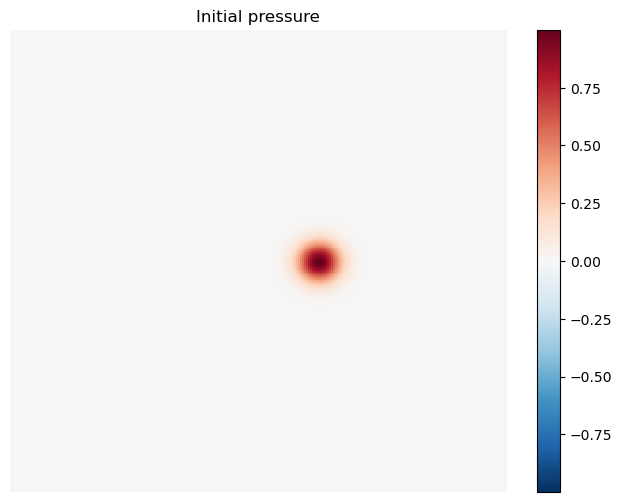

In [3]:

# Defining the initial pressure
N = domain.N

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([-0, 12e-3])/domain.dx[0] + np.array(N)/2
sigma = 3e-3/domain.dx[0]
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

p0 = FourierSeries(p0, domain)

show_field(p0)
plt.title("Initial pressure")
plt.show()

In [4]:
num_sensors = 64
rx = 45e-3
ri = rx/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))
sensors_positions = (xi, yi)
sensors = Sensors(positions=sensors_positions)

In [5]:
@jit
def compiled_simulator(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0, sensors=sensors)
    return a

@jit
def compiled_simulator2(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0)
    return a

p = compiled_simulator2(medium, p0)
sensors_data = compiled_simulator(medium, p0)[..., 0]


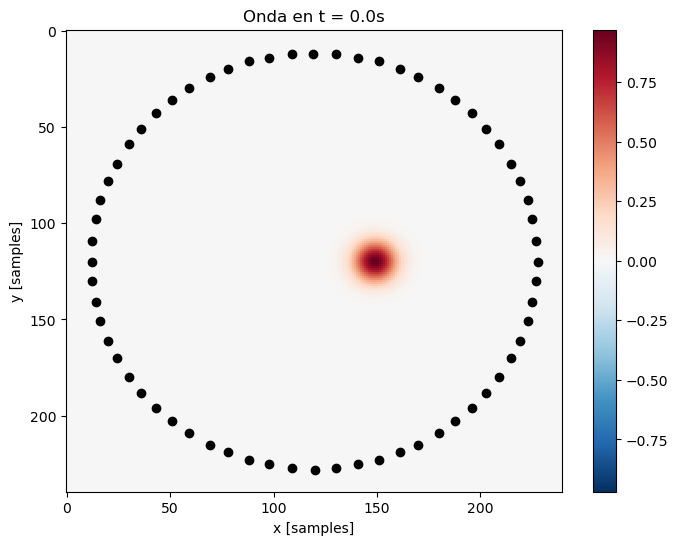

In [6]:
Nt = int(time_axis.Nt)
it = 0
i = it if it < Nt else Nt

show_field(p[i], "Onda en t = " + str(i*dt) + "s")
plt.scatter(xi, yi, c='black')
plt.xlabel("x [samples]")
plt.ylabel("y [samples]")
plt.axis("on")
plt.show()

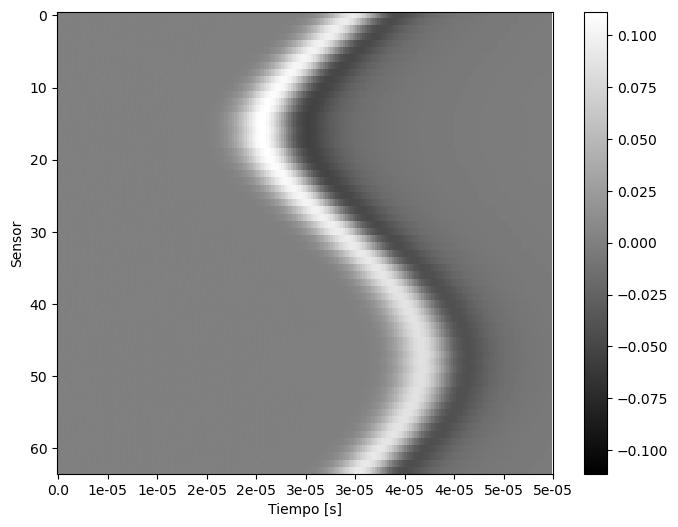

In [7]:
_field = FourierSeries(sensors_data.T, domain)
sinogram = _field.on_grid

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray", #"RdBu_r"
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)

plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=5))
#plt.title("Sinograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
plt.show()

In [ ]:
WaveEquationConstantVelocity3D()

t = time_axis.to_array()
x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]

batch_shape = (len(x), t.shape[0])

xx, tt = np.meshgrid(x, t, indexing="xy")
yy, _ = np.meshgrid(y, t, indexing="xy")

const, model = load_model(run="test", i=100000, rootdir="pulse_2d_real1/results/")
_, all_params, _, active, _ = model

sinogram_fbpinn = FBPINN_solution(const, all_params, active, np.c_[xx.T.flatten(), yy.T.flatten(), tt.T.flatten()]).reshape(batch_shape)
sinogram_fbpinn = fw.shift_solution_sinogram(sinogram_fbpinn, rx, 1490, np.array([-0, 12e-3]),np.c_[x,y], time_axis.dt)


[INFO] 2025-10-29 13:18:24 - Loading model from:
pulse_2d_real1/results/models/test/model_00100000.jax
[INFO] 2025-10-29 13:18:26 - x_batch
[INFO] 2025-10-29 13:18:26 - (12864, 3), float64, ndarray
[INFO] 2025-10-29 13:18:26 - x_take
[INFO] 2025-10-29 13:18:26 - (230748, 3), float64, ndarray


4.791e-05


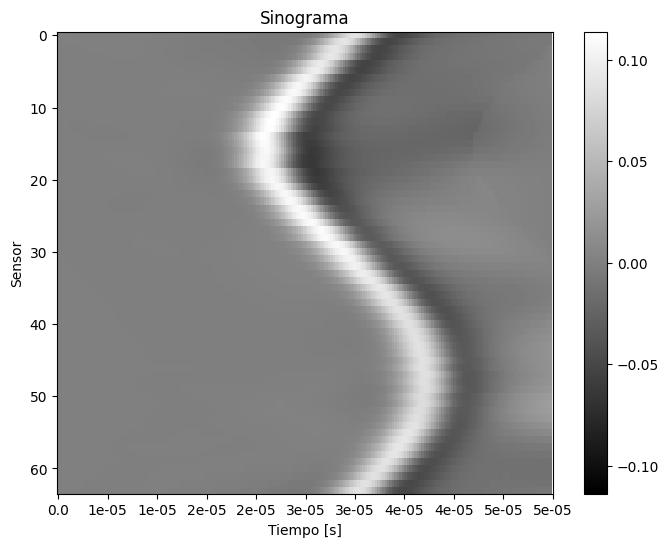

In [332]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray", #"RdBu_r"
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=5))
plt.title("Sinograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
print(ecm)
plt.show()

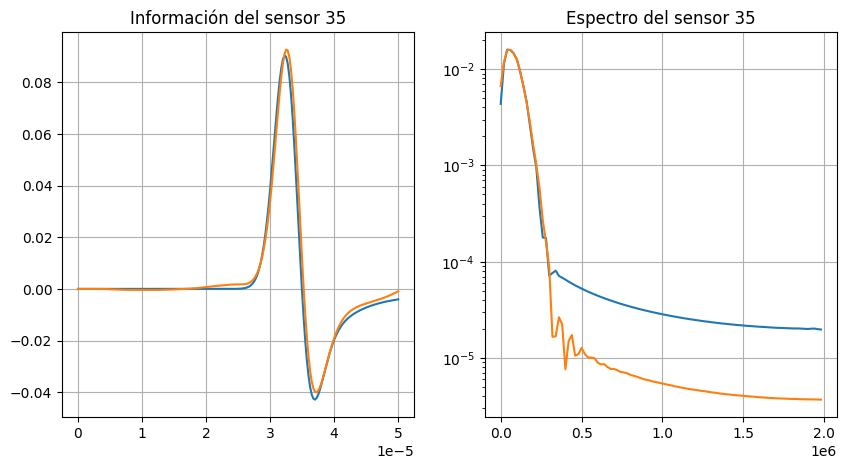

In [333]:
id = 35
sensor = sinogram[id,:]
sensor_fbpinn = sinogram_fbpinn[id,:]
t_axis = time_axis.to_array()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title(f"Información del sensor {id}")
plt.plot(t_axis, sensor)
plt.plot(t_axis, sensor_fbpinn)
plt.grid()

from scipy.fft import fft, fftfreq

N = 200

T = time_axis.dt

x = np.linspace(0.0, N*T, N, endpoint=False)

yf = fft(sensor)
yf_fbpinn = fft(sensor_fbpinn)

xf = fftfreq(N, T)[:N//2]

plt.subplot(1,2,2)
plt.title(f"Espectro del sensor {id}")

plt.semilogy(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.semilogy(xf, 2.0/N * np.abs(yf_fbpinn[0:N//2]))

plt.grid()

plt.show()

## Figura de mérito

In [334]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

rmse  = np.sqrt(np.mean(ec))
rmse = np.format_float_scientific(rmse, precision=3)

range = (np.max(sinogram) - np.min(sinogram))

psnr =  10*np.log10(range**2 / np.mean((sinogram - sinogram_fbpinn)**2))
psnr = peak_signal_noise_ratio(sinogram, sinogram_fbpinn)


ssim = structural_similarity(sinogram, sinogram_fbpinn, data_range=range)

pcc, _ = pearsonr(sinogram.flatten(), sinogram_fbpinn.flatten())

print(f"MSE = {ecm}")
print(f"RMSE = {rmse}")
print(f"PSNR = {psnr}")
print(f"SSIM = {ssim}")
print(f"PCC = {pcc}")

MSE = 4.791e-05
RMSE = 6.922e-03
PSNR = 49.21644492327053
SSIM = 0.7079128737810125
PCC = 0.9645388722419739


In [337]:
from delayandsum import applyDAS
Pjwave = applyDAS(sinogram.shape[0],sinogram.shape[1],120e-6,128,rx,360,1490,0,50e-6,sinogram).T
Pfbpinn = applyDAS(sinogram.shape[0],sinogram.shape[1],120e-6,128,rx,360,1490,0,50e-6,sinogram_fbpinn).T

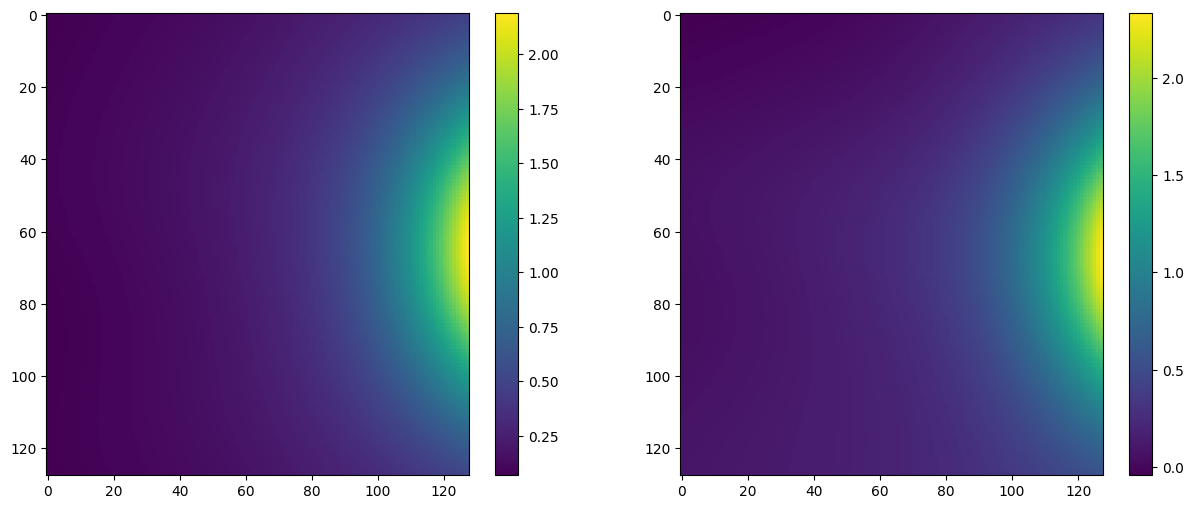

In [338]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
maxval = jnp.amax(jnp.abs(Pjwave))
plt.imshow(
    Pjwave,
    aspect="auto",
)
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(
    Pfbpinn,
    aspect="auto",
)
plt.colorbar()

In [339]:
ec = (Pjwave - Pfbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

rmse  = np.sqrt(np.mean(ec))
rmse = np.format_float_scientific(rmse, precision=3)

range = (np.max(Pjwave) - np.min(Pjwave))

psnr =  10*np.log10(range**2 / np.mean((Pjwave - Pfbpinn)**2))
psnr = peak_signal_noise_ratio(Pjwave, Pfbpinn, data_range=range)


ssim = structural_similarity(Pjwave, Pfbpinn, data_range=range)

pcc, _ = pearsonr(Pjwave.flatten(), Pfbpinn.flatten())

print(f"MSE = {ecm}")
print(f"RMSE = {rmse}")
print(f"PSNR = {psnr}")
print(f"SSIM = {ssim}")
print(f"PCC = {pcc}")

MSE = 5.114e-03
RMSE = 7.151e-02
PSNR = 29.433301759706765
SSIM = 0.8954633229061175
PCC = 0.9898492156539782
